In [57]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString


%matplotlib inline

# Allow inline jshtml animations
from matplotlib import rc
rc('animation', html='jshtml')

import anuga 
#newmesh = anuga.pmesh.mesh.importMeshFromFile('merimbula_10785.tsh')
newmesh = anuga.pmesh.mesh.importMeshFromFile('merimbula_17156.tsh')
newmesh = anuga.pmesh.mesh.importMeshFromFile('test.tsh')

newmesh



        mesh Triangles: [[321, 1355, 282], [7745, 3567, 3377], [5605, 2965, 5604], [1355, 1080, 2211], [7202, 7203, 1654], [1261, 3026, 3029], [6296, 1571, 6034], [1571, 1234, 5510], [1570, 6542, 6032], [546, 6104, 174], [2046, 613, 5224], [5706, 26, 5707], [5961, 475, 8175], [6630, 613, 2046], [338, 2958, 1204], [1434, 3656, 1411], [307, 364, 6176], [4313, 2172, 2174], [599, 2208, 6727], [2958, 177, 6457], [2914, 1033, 2912], [3255, 3252, 1797], [7412, 1025, 7411], [282, 2211, 47], [1743, 6425, 6426], [5248, 6201, 1055], [6028, 1878, 67], [6501, 6502, 5195], [6516, 540, 6517], [7092, 2433, 6871], [540, 625, 6517], [6519, 6518, 1875], [2095, 91, 673], [2768, 7100, 722], [2210, 1095, 6729], [4535, 6723, 2197], [3783, 7880, 8942], [3380, 8486, 3379], [2095, 1226, 6028], [195, 6084, 673], [1305, 4904, 5429], [5510, 5509, 84], [508, 4831, 8692], [5211, 8551, 8751], [6295, 783, 503], [7394, 1770, 5163], [5583, 5582, 1188], [6028, 67, 91], [5576, 5573, 1307], [2663, 2660, 1435], [8124, 3986

newmesh

In [41]:
print(len(newmesh.getMeshSegmentTags()))
print(len(newmesh.getMeshSegments()))
print(len(newmesh.getUserSegments()))
print(newmesh.getMeshSegments().tolist())

meshsegmenttags = newmesh.getMeshSegmentTags()
meshvertices = newmesh.getMeshVertices().tolist()
usersegments = newmesh.getUserSegments()
meshsegments = newmesh.getMeshSegments().tolist()


1365
1365
855
[[420, 8165], [355, 733], [559, 291], [503, 167], [461, 692], [4910, 79], [783, 84], [340, 350], [221, 2628], [6464, 225], [784, 4562], [264, 6165], [831, 6438], [257, 223], [47, 167], [7111, 583], [85, 302], [215, 518], [554, 823], [615, 620], [618, 711], [159, 103], [762, 7789], [824, 760], [147, 618], [42, 51], [490, 552], [1976, 359], [10, 718], [819, 295], [4823, 251], [340, 263], [813, 390], [387, 6506], [639, 770], [683, 764], [248, 724], [648, 6471], [109, 105], [8279, 796], [2428, 736], [289, 7906], [82, 406], [1703, 715], [55, 260], [55, 222], [579, 592], [173, 95], [22, 656], [3178, 4], [255, 585], [627, 54], [25, 7787], [800, 6461], [805, 5960], [476, 522], [6781, 2160], [598, 6661], [107, 6869], [7091, 484], [635, 14], [325, 9], [816, 4362], [268, 704], [32, 104], [7222, 528], [717, 805], [472, 482], [574, 756], [628, 671], [694, 291], [452, 743], [29, 362], [4112, 622], [274, 8171], [2096, 668], [567, 828], [530, 370], [322, 137], [469, 33], [634, 181], [253

In [42]:
for i, tag in enumerate(meshsegmenttags):
    if tag == 'open':
        print (i, tag, meshsegments[i], meshvertices[meshsegments[i][0]], meshvertices[meshsegments[i][1]])

In [26]:
for i,seg in enumerate(usersegments):
    if seg.tag == 'open':
        print(i,seg.tag, [seg.vertices[0].x, seg.vertices[0].y], [seg.vertices[1].x, seg.vertices[1].y])

21 open [761052.7, 5912151.0] [759608.8, 5912326.0]


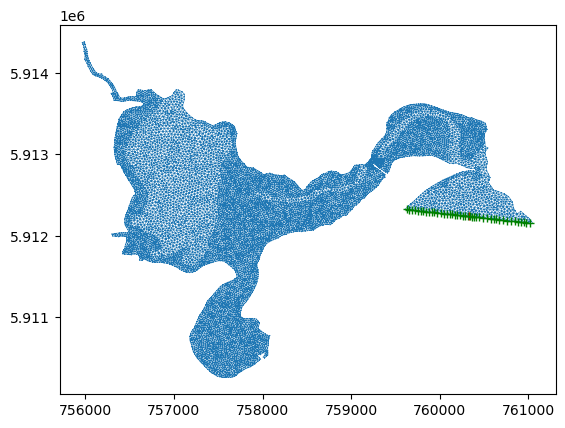

In [61]:
ax = domain.triplot(linewidth = 0.4)
#ax.set_xlim(761052.7,759608.8)
#ax.set_ylim(5912151.0,5912326.0)

p0 = np.array([761052.7, 5912151.0])
p1 = np.array([759608.8, 5912326.0])

start = Point(p0)
end   = Point(p1)
x0 = 0.5*(p0[0]+p1[0])
y0 = 0.5*(p0[1]+p1[1])
ax.plot(x0,y0,'r+')

line = LineString([start, end]) 

for i in range(len(meshsegmenttags)):
    tag = meshsegmenttags[i]

    #meshsegmenttags[i] = 'exterior'
    #if tag == 'open':
    x0 = meshvertices[meshsegments[i][0]][0]
    y0 = meshvertices[meshsegments[i][0]][1]
    x1 = meshvertices[meshsegments[i][1]][0]
    y1 = meshvertices[meshsegments[i][1]][1]

    xm = 0.5*(x0+x1)
    ym = 0.5*(y0+y1)

    q0 = Point(xm,ym)
    
    if (line.distance(q0) < 1.0e-2) and (line.project(q0)/line.length):
        #print(tag,xm,ym,line.distance(q0), line.project(q0)/line.length)
        #meshsegmenttags[i] = 'open'
        ax.plot(xm,ym,'g+')
    elif tag == 'exterior':
        pass
    else:
        print("Problem")
  

In [55]:
newmesh.export_mesh_file('test.tsh')

In [56]:
%ls

anuga_pmesh_gui.log                                merimbula_17156_refined.tsh
meri0.pts                                          merimbula_17156.tsh
meri0.xya                                          merimbula_17540_refined.tsh
merimbula_10785_1.tsh                              merimbula_17540_refined.zip
merimbula_10785_5.msh                              merimbula_43200.tsh
merimbula_10785_5.tsh                              merimbula_bathymetry.pts
merimbula_10785.tsh                                merimbula_bathymetry.xya
merimbula_17156_refined_bathymetry_alpha_0.01.tsh  merimbula_interpolated.zip
merimbula_17156_refined_bathymetry_alpha_0.1.tsh   _plot/
merimbula_17156_refined_bathymetry_alpha_10.tsh    test.tsh
merimbula_17156_refined_bathymetry_alpha_1.tsh     test.txt
merimbula_17156_refined_bathymetry_alpha_pt5.tsh   Untitled.ipynb
